**The Objective**

**Is a 0.5 threshold always the best choice in Logistic Regression?**

Analyze if the standard threshold of $0.5$ always yields the most desirable results in various scenarios.

Investigate alternative thresholds and how they can improve model performance depending on the problem context.



# ROC curves

When we denote $1$ - true positive value, $0$ - true negative value, $\pm$ - identified as positive and negative respectively, then
$$
\mathrm{Sensitivity} = \mathbb{P}(+\mid 1)
$$
and
$$
\mathrm{Specificity} = \mathbb{P}(-\mid 0).
$$

For every point on the ROC curve (representing a different threshold value), the location of that point is plotted as the sensitivity at that cutoff value on the $Y$ axis, and $1$-specificity at that cutoff value on the $X$ axis. **It represents the trade-off between the True Positive Rate and False Positive Rate of a classifier**, i.e.

$$
\mathrm{Specificity} = \mathbb{P}(-\mid 0) = 1 - \mathbb{P}(+\mid 0) = 1 - \mathrm{FPR},
$$
where $\mathrm{FPR} = \mathbb{P}(+\mid 0)$.

# Area Under the Curve (AUC)

The area under the ROC curve (AUC) represents the probability that a model, given a randomly chosen positive and negative example, will rank the positive example higher than the negative one.

How it works
1. Randomly select one example from the positive class 1 and one from the negative class 0.  
2. Compare the model's predicted scores (or probabilities):
   - If the positive example receives a higher score than the negative one, this is a **correct ranking**.
   - If it receives a lower score, this is an **incorrect ranking**.
   - If both scores are equal, this is counted as a **tie** (typically 0.5).
3. Repeat this process for all possible positive–negative pairs.

Formula
$$
  \mathrm{AUC} = \frac{|\{(i,j): y_i = 1,\, y_j = 0,\, s_i > s_j\}| + |\{(i,j): y_i = 1,\, y_j = 0,\, s_i = s_j\}|/2}{|\{i: y_i = 1\}| \cdot |\{j: y_j = 0\}|}
$$

Interpretation

$\mathrm{AUC} = 1$ represents perfect classifier, $\mathrm{AUC} = 0.5$ is roughly equivalent to random guessing and values lower than $0.5$ indicate worse than random classification.

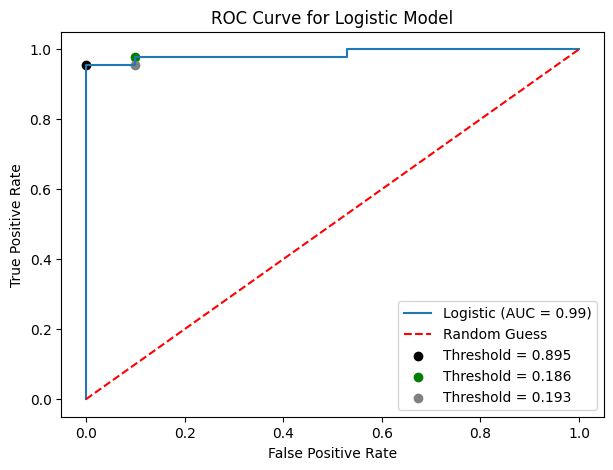

Threshold: 0.895, FPR: 0.00, TPR: 0.95
Threshold: 0.186, FPR: 0.10, TPR: 0.98
Threshold: 0.193, FPR: 0.10, TPR: 0.95
Target names: ['malignant' 'benign']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler


data = load_breast_cancer()
X, y = data.data, data.target
target_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

X_train, X_cv, y_train, y_cv = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42
    )

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_cv_scaled = scaler.transform(X_cv)

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

#malignant class probabillity
y_pred_prob = logistic_model.predict_proba(X_cv_scaled)[:, 0]

#ROC
fpr, tpr, thresholds = roc_curve(y_cv, y_pred_prob, pos_label=0)
roc_auc = auc(fpr, tpr)

#looking for best thresholds
J = tpr - fpr
idxes = np.argsort(J)[-3:][::-1]
colors = np.array(['black', 'green', 'gray'])
threshold_choices = np.array([thresholds[j] for j in idxes])

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Logistic (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
for j, idx in enumerate(idxes):
  t = thresholds[idx]
  plt.scatter(
      fpr[idx],
      tpr[idx],
      marker='o',
      color=colors[j],
      label=f'Threshold = {t:.3f}'
  )
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Model')
plt.legend()
plt.show()

for idx in idxes:
  print(f"Threshold: {thresholds[idx]:.3f}, FPR: {fpr[idx]:.2f}, TPR: {tpr[idx]:.2f}")

print("Target names:", target_names)

After ranking the three best thresholds using Youden’s J statistic,
$$
  J = \mathrm{Sensitivity} + 1 - \mathrm{Specificity},
$$
we observe the following trade-offs:

For Threshold = $0.895$, the model achieves FPR = 0, meaning there are no false positives, while correctly identifying $95\%$ of malignant cases (high sensitivity with zero false alarms).

For Threshold = $0.186$, the model correctly identifies $98\%$ of malignant cases, at the cost of an increase in the false positive rate to $10\%$.

# F1 - score

Formula:
$$
  \mathrm{F1} = \frac{2\mathrm{TP}}{2\mathrm{TP} + \mathrm{FP} + \mathrm{FN}}.
$$

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

X_test_scaled = scaler.transform(X_test)
y_test_prob = logistic_model.predict_proba(X_test_scaled)[:, 0]

def evaluate_metrics(threshold):
  y_test_pred = np.where(y_test_prob >= threshold, 0, 1)

  accuracy = accuracy_score(y_test, y_test_pred)
  precision = precision_score(y_test, y_test_pred, pos_label=0)
  recall = recall_score(y_test, y_test_pred, pos_label=0)
  f1 = f1_score(y_test, y_test_pred, pos_label=0)

  cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
  tp = cm[0, 0]   #malignant correctly predicted malignant
  fn = cm[0, 1]   #malignant predicted benign
  fp = cm[1, 0]   #benign predicted malignant
  tn = cm[1, 1]   #benign correctly predicted benign

  sensitivity = tp / (tp + fn)
  specificity = tn / (tn + fp)

  print(f"\nThreshold: {threshold:.3f}")
  print(f"Accuracy: {accuracy:.3f}")
  print(f"Precision (malignant): {precision:.3f}")
  print(f"Sensitivity (malignant recall): {sensitivity:.3f}")
  print(f"Specificity: {specificity:.3f}")
  print(f"F1-score: {f1:.3f}")

evaluate_metrics(thresholds[idxes[0]])


Threshold: 0.895
Accuracy: 0.965
Precision (malignant): 1.000
Sensitivity (malignant recall): 0.907
Specificity: 1.000
F1-score: 0.951


In [ ]:
evaluate_metrics(thresholds[idxes[1]])


Threshold: 0.186
Accuracy: 0.956
Precision (malignant): 0.913
Sensitivity (malignant recall): 0.977
Specificity: 0.944
F1-score: 0.944


In [ ]:
#Compare predictions at two thresholds
y_test_pred_1 = np.where(y_test_prob >= thresholds[idxes[0]], 0, 1)  # threshold = 0.895
y_test_pred_2 = np.where(y_test_prob >= thresholds[idxes[1]], 0, 1)  # threshold = 0.186

print("After going for the lower threshold:")
print(f"Changed to true positive: {np.sum((y_test == 0) & (y_test_pred_1 == 1) & (y_test_pred_2 == 0))}")
print(f"Changed to false positive: {np.sum((y_test == 1) & (y_test_pred_1 == 1) & (y_test_pred_2 == 0))}")

After going for the lower threshold:
Changed to true positive: 3
Changed to false positive: 4


We can see that in the second case sensitivity is higher because the number of false negatives decreases. However, the F1-score drops because the increase in false positives lowers precision, and this decrease outweighs the gain in recall.